# Double-Layer And Adjoint Double-Layer Kernels On The Sphere

This notebook is a self-contained walkthrough of how `SkelFMM` is used for **geometry-aware boundary kernels** on a sphere. The geometry is a triangular panelization of the unit sphere, and each panel contributes:

- a panel center $y_j$
- an outward unit normal $n_j$
- an area weight $w_j$

The examples here focus on two operator families:

- the **double-layer kernel**, which differentiates the Green's function with respect to the **source** normal
- the **adjoint double-layer kernel**, which differentiates the Green's function with respect to the **target** normal

Both the **Laplace** kernel and the **Helmholtz** kernel fit the same kernel-independent framework. The tree construction, proxy interactions, recursive skeletonization, and fast apply machinery stay the same; only the kernel evaluation changes, together with whether the normals are attached on the source side or the target side.

The notebook is intentionally lightweight. It does **not** run the full convergence studies, since those are better launched from the packaged example scripts on the target machine. Instead, this notebook does three things:

- visualizes the sphere panel geometry and normals
- explains how the weighted density and normals are passed into `SkelFMM`
- builds the Laplace and Helmholtz double-layer operators together with their adjoints, and checks the corresponding adjoint identities

For the larger convergence runs, use:

- `python -m skelfmm.examples.convergence_laplace_double_layer_sphere`
- `python -m skelfmm.examples.convergence_helmholtz_double_layer_sphere`


In [1]:
n_points = 5120
plot_n_points = 1280
n_normal_samples = 80
tol = 1e-4
leaf_size = 200
use_single_precision = True

print(f'n_points = {n_points}')
print(f'tol = {tol:.1e}')
print(f'leaf_size = {leaf_size}')


n_points = 5120
tol = 1.0e-04
leaf_size = 200


In [2]:
import matplotlib.pyplot as plt
import numpy as np

from skelfmm import SkelFMM, operators
from skelfmm.examples.util.geometry_utils import make_icosphere_mesh, triangle_panel_geometry


## Sphere Geometry

The double-layer kernels depend on the panel normals. We discretize the unit sphere by triangular panels and attach to each panel:

- a panel center $y_j$
- an outward unit normal $n_j$
- an area weight $w_j$

The figure below shows the panel mesh together with a subsampled set of outward normals.


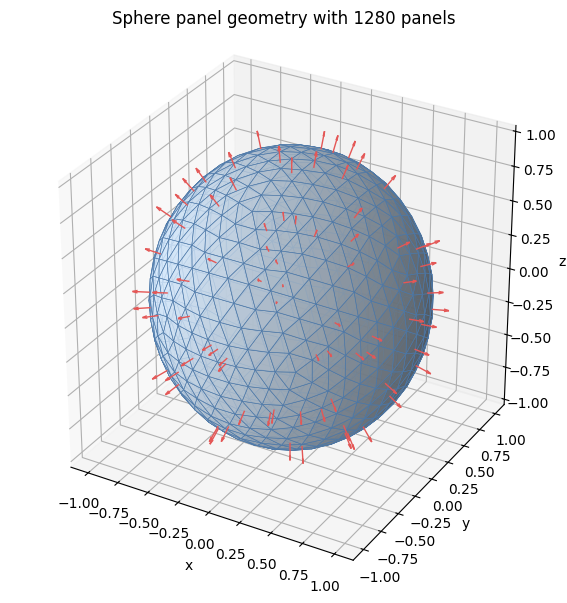

In [3]:
V, F = make_icosphere_mesh(n_panels=plot_n_points, radius=1.0)
xx, nu, area = triangle_panel_geometry(V, F)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(V[:, 0], V[:, 1], V[:, 2], triangles=F, color='#d9ecff', edgecolor='#4c78a8', linewidth=0.45, alpha=0.8)

sample = np.linspace(0, xx.shape[0] - 1, min(n_normal_samples, xx.shape[0]), dtype=int)
scale = 0.12
ax.quiver(
    xx[sample, 0], xx[sample, 1], xx[sample, 2],
    nu[sample, 0], nu[sample, 1], nu[sample, 2],
    length=scale, normalize=True, color="#e45756", linewidth=1.0,
)

ax.set_title(f'Sphere panel geometry with {plot_n_points} panels')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_box_aspect((1, 1, 1))
plt.tight_layout()
plt.show()


## Geometry-Aware Kernel View

For both Laplace and Helmholtz, the sphere panelization provides three pieces of data for each panel $j$:

- a panel center $y_j$
- an outward unit normal $n_j$
- an area weight $w_j$

The source vector given to `SkelFMM` is the quadrature-weighted density

$$
q_j = w_j \, \sigma_j,
$$

while the panel normals are passed separately as geometry metadata.

For the double-layer kernel, the fast apply computes

$$
u(x_i) \approx \sum_j D(x_i, y_j) \, q_j,
$$

where the kernel itself uses the **source** normals through the normal derivative with respect to $y_j$.

For the adjoint double-layer kernel, the fast apply computes

$$
u^*(x_i) \approx \sum_j D^*(x_i, y_j) \, q_j,
$$

and now the kernel uses the **target** normals through the normal derivative with respect to $x_i$.

So the kernel-independent part of the method stays fixed: the tree, proxy interactions, recursive skeletonization, and fast apply machinery are unchanged. Only the kernel evaluation changes, together with whether the geometry is attached on the source side or the target side.


In [4]:
vertices, faces = make_icosphere_mesh(n_panels=n_points, radius=1.0)
points, normals, area = triangle_panel_geometry(vertices, faces)

def run_adjoint_check(*, operator, adjoint_operator, kappa, complex_density, seed=0):
    random = np.random.RandomState(seed)
    if complex_density:
        sigma = random.randn(points.shape[0]) + 1j * random.randn(points.shape[0])
        eta = random.randn(points.shape[0]) + 1j * random.randn(points.shape[0])
    else:
        sigma = random.randn(points.shape[0])
        eta = random.randn(points.shape[0])

    weighted_sigma = area * sigma

    fmm_double = SkelFMM(
        points,
        operator,
        geometry=normals,
        param=kappa,
        tol=tol,
        leaf_size=leaf_size,
        use_single_precision=use_single_precision,
    )

    fmm_adjoint = SkelFMM(
        points,
        adjoint_operator,
        geometry=normals,
        param=kappa,
        tol=tol,
        leaf_size=leaf_size,
        use_single_precision=use_single_precision,
    )

    double_out = fmm_double.apply(weighted_sigma)
    adjoint_out = fmm_adjoint.apply(eta)

    lhs = np.dot(double_out, eta)
    rhs = np.dot(weighted_sigma, adjoint_out)
    adjoint_relerr = abs(lhs - rhs) / max(abs(lhs), abs(rhs), 1e-30)

    return adjoint_relerr


## Laplace Double-Layer And Adjoint Double-Layer

For Laplace,

$$
G_0(x,y) = \frac{1}{4\pi |x-y|},
$$

and the two kernels are

$$
D_0(x,y) = -\partial_{n_y} G_0(x,y), \qquad D_0^*(x,y) = -\partial_{n_x} G_0(x,y).
$$

The next cell builds both operators on the same sphere panelization and checks the discrete bilinear identity

$$
\langle D_0(w\sigma), \, \eta \rangle = \langle w\sigma, \, D_0^* \eta \rangle.
$$


In [5]:
laplace_relerr = run_adjoint_check(
    operator=operators.LAPLACE_DOUBLE_LAYER_3D,
    adjoint_operator=operators.LAPLACE_ADJOINT_DOUBLE_LAYER_3D,
    kappa=0.0,
    complex_density=False,
)

print(f'Laplace adjoint relative error: {laplace_relerr:.3e}')


Laplace adjoint relative error: 1.218e-07


## Helmholtz Double-Layer And Adjoint Double-Layer

For Helmholtz,

$$
G_\kappa(x,y) = \frac{e^{i\kappa |x-y|}}{4\pi |x-y|},
$$

and the two kernels are

$$
D_\kappa(x,y) = -\partial_{n_y} G_\kappa(x,y), \qquad D_\kappa^*(x,y) = -\partial_{n_x} G_\kappa(x,y).
$$

The next cell repeats the same construction for a nonzero wave number and checks the corresponding adjoint identity.


In [6]:
helmholtz_kappa = 5.0

helmholtz_relerr = run_adjoint_check(
    operator=operators.HELMHOLTZ_DOUBLE_LAYER_3D,
    adjoint_operator=operators.HELMHOLTZ_ADJOINT_DOUBLE_LAYER_3D,
    kappa=helmholtz_kappa,
    complex_density=True,
)

print(f'Helmholtz kappa = {helmholtz_kappa:.1f}')
print(f'Helmholtz adjoint relative error: {helmholtz_relerr:.3e}')


Helmholtz kappa = 5.0
Helmholtz adjoint relative error: 2.284e-07
